---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.2 (Math Behind Simple Linear Regression)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook
1. Statistics (A Recap)
    - Variance and Standard Deviation
    - Covariance
    - Correlation
2. Regression?
    - What is Regression?
    - Correlation vs Regression
    - Types of Regression
    - Simple Linear Regression
    - An Intuitive Understanding of Simple Linear Regression
    - An Intuition of Ordinary Least Squares Method (OLS)
    - Minimize the Cost Function to Derive $\beta_0$ and $\beta_1$
    - Derivation of  $\beta_1$, and $\beta_0$ for Best Fit Regression Line using OLS Method
3. Example (Simple Linear Regression using OLS) 
    - Understand the dataset
    - Calculate the Regression Coefficients
    - Draw the Best Fit Line
    - Carry out Prediction
4. How to Evaluate the Regression Models?
    - Evaluation Metrics
    - Residual Plots, Homoscedasticity and Heteroscedasticity
5. Task To Do

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# 1. Statistics (A Recap)
- **Statistics** is the area of applied mathematics that deals with data collection & organization, data analysis, data interpretation and data representation.
    - `Descriptive Statistics` is used to describe, summarize, and present different datasets through numerical calculations and graphs.
    - `Inferential Statistics` is used to make prediction and inferences for an entire population based on sample data from that population
    
>- <font color=green size=3> Descriptive Statistics:</font> https://www.youtube.com/watch?v=Q6EZ-KGm3UE&list=PL7B2bn3G_wfDTEU20jwGcUKlVqdAyQMax&index=1
>- <font color=green size=3>Inferential Statistics:</font> https://www.youtube.com/watch?v=y4t9ELO3Nxc&list=PL7B2bn3G_wfDTEU20jwGcUKlVqdAyQMax&index=2

## a. Variance and Standard Deviation

<img align="right" width="400" height="750"  src="images/bellcurve.png"  >

- **`Variance`** or **`standard deviation`** tells us how much a (single) variable/quantity varies w.r.t. its mean 'OR' how spread out the data is around the center of the distribution (the mean).  
- The value of variance doesn't give us any information, so we take its square root to calculate the `Standard Deviation`.
$$ \large \sigma_x  = \sqrt{\frac{\sum(x_i - \bar{x})^2}{n-1}}$$

In [3]:
import numpy as np
x = np.array([0,5,20,40,45])
n = len(x)
print("Mean: ", np.mean(x))
print("Standard Deviation: {:.3f}".format(np.sqrt(np.sum((x - np.mean(x))**2)/(n))))


Mean:  22.0
Standard Deviation: 18.055


In [1]:
import numpy as np
x = np.array([10,15,20,30,35])
n = len(x)
print("Mean: ", np.mean(x))
print("Standard Deviation: {:.3f}".format(np.sqrt(np.sum((x - np.mean(x))**2)/(n))))


Mean:  22.0
Standard Deviation: 9.274


In [6]:
import numpy as np
x = np.array([28,31,40,29,33,38])
n = len(x)
print("Mean: ", np.mean(x))
print("Standard Deviation: {:.3f}".format(np.sqrt(np.sum((x - np.mean(x))**2)/(n))))


Mean:  33.166666666666664
Standard Deviation: 4.450


In [7]:
import numpy as np
x = np.array([1,28,100, 120, 10, 95,31,40,29,33,38])
n = len(x)
print("Mean: ", np.mean(x))
print("Standard Deviation: {:.3f}".format(np.sqrt(np.sum((x - np.mean(x))**2)/(n))))


Mean:  47.72727272727273
Standard Deviation: 37.158


#### Example 1:

In [1]:
import numpy as np
x = np.array([1,0,2,6,4,3,3])
y= np.array([95,90,90,55,70,80,85])
n = len(x)
print("Mean x: ", np.mean(x))
print("Meany: ", np.mean(y))
print("Standard Deviation: {:.3f}".format(np.sqrt(np.sum((x - np.mean(x))**2)/(n))))

cov1 = (np.sum(np.multiply(x-np.mean(x), y-np.mean(y))))/(n)
print("Covariance: ", cov1)

Mean x:  2.7142857142857144
Meany:  80.71428571428571
Standard Deviation: 1.829
Covariance:  -21.938775510204085


In [2]:
import numpy as np
x = np.array([68, 69, 64, 60, 64, 63, 64, 68, 65, 66])
n = len(x)
print("Mean: ", np.mean(x))
print("Standard Deviation: {:.3f}".format(np.sqrt(np.sum((x - np.mean(x))**2)/(n-1))))
print("Standard Deviation: {:.3f}".format(np.std(x, ddof=1)))

Mean:  65.1
Standard Deviation: 2.726
Standard Deviation: 2.726


> <font color=green size=3> Low standard deviation implies that most values in the dataset are close to the mean. </font>

#### Example 2:

In [3]:
x = np.array([4, 95, 5, 60, 76, 1, 93, 84, 71, 100])
n = len(x)
n = len(x)
print("Mean: ", np.mean(x))
print("Standard Deviation: {:.3f}".format(np.sqrt(np.sum((x - np.mean(x))**2)/(n-1))))
print("Standard Deviation: {:.3f}".format(np.std(x, ddof=1)))

Mean:  58.9
Standard Deviation: 40.134
Standard Deviation: 40.134


> <font color=green size=3>High standard deviation implies that the values in the dataset are more broadly spread out.</font>

## b. Covariance
- **`Covariance`** measures the direction of the relationship between two random variables, and its value range from negative infinity to positive infinity.
- It tells us how two variables/quantities, $x$ and $y$ are related to each other or how the mean values of two random variales move together.
- It can be calculated using following formula:<br><br>
$$ \large \text{cov}(x, y) \hspace{.5cm}=\hspace{.5cm} \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) }{n-1} \hspace{.5cm}=\hspace{.5cm} \frac{n(\bar{(x_iy_i)} - \bar{x}\bar{y})}{n-1} \hspace{.5cm}=\hspace{.5cm} \frac{n\sum{x_iy_i} - \sum{x_i} \sum{y_i}}{n(n-1)}$$


In [4]:
import seaborn as sns
from matplotlib import pyplot as plt

#### Example 1:

Covariance: 2.167
Covariance: 2.167
Covariance: 2.167
Covariance: 
 [[4.66666667 2.16666667]
 [2.16666667 1.04285714]]


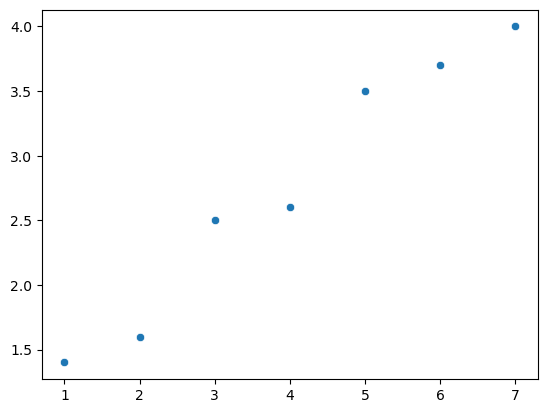

In [5]:
x = np.array([1,   2,   3,   4,   5,   6,   7.])               # study hours 
y = np.array([1.4, 1.6, 2.5, 2.6, 3.5, 3.7, 4.0])   # gpa
n = len(x)
cov1 = (np.sum(np.multiply(x-np.mean(x), y-np.mean(y))))/(n-1)
cov2 = ((n*((np.mean(x*y))-(np.mean(x)*np.mean(y)))))/ (n-1)
cov3 = ((n*(np.sum(x*y))) - ((np.sum(x)) * (np.sum(y))))  / (n*(n-1))
cov4 = np.cov(x,y)
print("Covariance: {:.3f}".format(cov1))
print("Covariance: {:.3f}".format(cov2))
print("Covariance: {:.3f}".format(cov3))
print("Covariance: \n",cov4)
sns.scatterplot(x=x,y=y);

> <font color=green size=3>Positive covariance indicates that two variables tend to move in the same direction. </font>

#### Example 2:

Covariance: -2.816
Covariance: -2.816
Covariance:-2.816
Covariance: 
 [[ 6.         -2.81571429]
 [-2.81571429  1.34362143]]


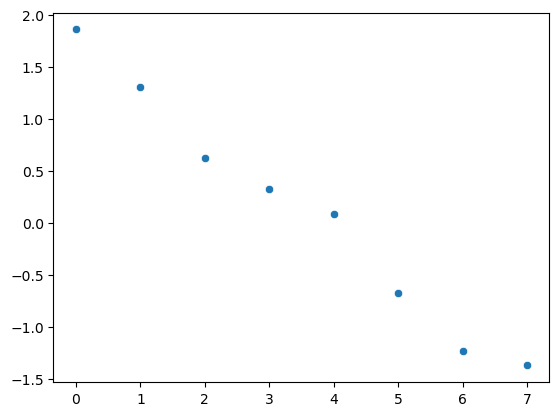

In [6]:
x = np.array([0, 1, 2, 3, 4, 5, 6, 7.])                         # Drug dosage in ml
y = np.array([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37])   # Level of forgetfullness
n = len(x)
cov1 = (np.sum(np.multiply(x-np.mean(x), y-np.mean(y))))/(n-1)
cov2 = ((n*((np.mean(x*y))-(np.mean(x)*np.mean(y)))))/ (n-1)
cov3 = ((n*(np.sum(x*y))) - ((np.sum(x)) * (np.sum(y))))  / (n*(n-1))
cov4 = np.cov(x,y)
print("Covariance: {:.3f}".format(cov1))
print("Covariance: {:.3f}".format(cov2))
print("Covariance:{:.3f}".format(cov3))
print("Covariance: \n", cov4)
sns.scatterplot(x=x,y=y);

> <font color=green size=3>Negative covariance indicates that two variables tend to move in the inverse direction. </font>

#### Example 3:

Covariance:  0.0
Covariance:  0.0
Covariance:  0.0
Covariance: 
 [[5.33333333 0.        ]
 [0.         5.33333333]]


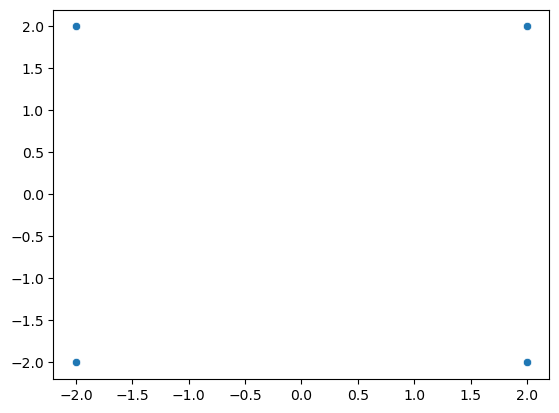

In [7]:
x = np.array([2, -2, -2, 2])                         
y = np.array([2, 2, -2, -2]) 
n = len(x)
cov1 = (np.sum(np.multiply(x-np.mean(x), y-np.mean(y))))/(n-1)
cov2 = ((n*((np.mean(x*y))-(np.mean(x)*np.mean(y)))))/ (n-1)
cov3 = ((n*(np.sum(x*y))) - ((np.sum(x)) * (np.sum(y))))  / (n*(n-1))
cov4 = np.cov(x,y)
print("Covariance: ", cov1)
print("Covariance: ", cov2)
print("Covariance: ", cov3)
print("Covariance: \n", cov4)
sns.scatterplot(x=x,y=y);

> <font color=green size=3>Zero covariance indicates that two variables have no relationship between each other.</font>

## c. Correlation

- **Correlation** tells us the direction as well as the magnitude of the relationship between two random variables, and the value of correlation coefficient ranges from -1 to +1
-  There are several types of correlation coefficients. `The Pearson Correlation Coefficient` (developed by Karl Pearson) denoted by $R$ or $\large \rho$ is the most common and is defined by: 

$$ \large R_{x,y}  = \frac{cov(x,y)}{\sigma_x \sigma_y} \hspace{2cm}.........(i)$$ 


$$ \large R_{x,y} = \frac{\sum(x_i -  \bar{x})(y_i -  \bar{y})}{\sqrt{\sum (x_i -  \bar{x})^2} \sqrt{\sum (y_i -  \bar{y})^2}}$$ 

$$ \hspace{2.5cm}\large R_{x,y} = \frac{n\sum(x_iy_i)-\sum x_i \sum y_i}{\sqrt{n\sum (x_i^2 -  (\sum x)^2} \sqrt{n\sum (y_i^2 -  (\sum y)^2}}$$ 

$$ \large R_{x,y} = \frac{1}{n-1}   \sum(\frac{x_i - \bar{x}}{\sigma_x})(\frac{y_i - \bar{y}}{\sigma_y})  $$ 

In [5]:
import numpy as np
import seaborn as sns

#### Example 1: 

Pearson Correlation Coefficient: 0.982


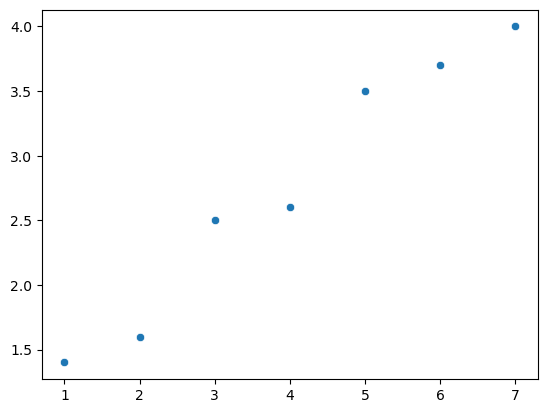

In [6]:
x = np.array([1,   2,   3,   4,   5,   6,   7.])               # study hours 
y = np.array([1.4, 1.6, 2.5, 2.6, 3.5, 3.7, 4.0])   # gpa
numerator = sum(np.multiply(x - np.mean(x), y - np.mean(y)))
denominator = np.multiply((np.sqrt(np.sum((x-np.mean(x))**2))), np.sqrt(np.sum((y-np.mean(y))**2)))
corr_coef = numerator / denominator
print("Pearson Correlation Coefficient: {:.3f}".format(corr_coef))

sns.scatterplot(x=x,y=y);

#### Example 2:

Pearson Correlation Coefficient: -0.992


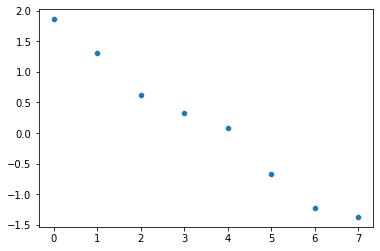

In [11]:
x = np.array([0, 1, 2, 3, 4, 5, 6, 7.])                         # Drug dosage in ml
y = np.array([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37])   # Level of forgetfullness
numerator = sum(np.multiply(x - np.mean(x), y - np.mean(y)))
denominator = np.multiply((np.sqrt(np.sum((x-np.mean(x))**2))), np.sqrt(np.sum((y-np.mean(y))**2)))
corr_coef = numerator / denominator
print("Pearson Correlation Coefficient: {:.3f}".format(corr_coef))
sns.scatterplot(x=x,y=y);

- The value of Correlation Coefficient always lie between -1 and +1. We can interpret as follows:
    - If $\rho_{x,y} = +1.0\hspace{1.2cm}$ then `Perfect Positive`linear relationship exist between two variables.
    - If $0.7 \leq \rho_{x,y} \lt +1.0$, then `Strong Positive`linear relationship exist between two variables.
    - If $0.3 \leq \rho_{x,y} \lt +0.7$, then `Moderate Positive`linear relationship exist between two variables.
    - If $-0.3 \leq \rho_{x,y} \lt +0.3$, then `Very Week`linear relationship exist between two variables.
    - If $-0.7 \leq \rho_{x,y} \lt -0.3$, then `Moderate Negative`linear relationship exist between two variables.
    - If $-1.0 \lt \rho_{x,y} \lt -0.7$, then `Strong Negative`linear relationship exist between two variables.
    - If $\rho_{x,y} = -1.0\hspace{1.2cm}$ then `Perfect Negative`linear relationship exist between two variables.

# 2. Regression?
    
## a. What is Regression?

- **Regression** is a statistical technique that relates a `dependent` variable to one or more `independent` variables.
- It is used to predict/forecast the value of a `dependent` variable based on the known values of the `independent` variable(s)
    - If output variable is a real value like salary, cost, gpa etc, then you are `predicting` present but unknown values.
    - If output variable is a real value like time, then you are `forecasting`.

## b. Correlation vs Regression
- Regression can differentiate between `dependent` and `independent` variables, while correlation cannot.
- The `reg(x,y)` and `reg(y,x)` are completely different, while the `corr(x,y)` and `corr(y,x)` are identical. 
- Regression can measure `causality` as well, while correlation just tell the direction of movement between two variables. 
- Regression can measure the strength and direction of both linear as well as non-linear relationship, while correlation can do this for linear relationship only.
- The graphical representation of a correlation is a single point, while a line visualizes a linear regression.


## c. Types of Regression?

<img align="right" width="400"  src="images/linear-nonlinear.jpeg"  >

- There are different types fo regression algorithms and these can be categorized based on the number of independent variables, shape of regression line, and type of dependent variable.
- Some common types are:
    - Simple Linear Regression
    - Multiple Linear Regression
    - Polynomial Regression
    - Logistic Regression
    - Ridge Regression
    - Lasso Regression
    - Bayesian Linear Regression
    - Support Vector Regression (SVR)
    - Decision Tree Regression

## d. Simple Linear Regression
- Linear regression is a type of model where the relationship between a dependent variable and one or more independent variables is assumed to be linear.
- There are two kinds of Linear Regression Model:
    - Simple Linear Regression: A linear regression model with one independent and one dependent variable.
    - Multiple Linear Regression: A linear regression model with more than one independent variable and one dependent variable.
    
| Dependent Variable ($y$) | Independent Variable ($x$) |
| ----------- | ----------- |
| GPA of a student | Number of hours studied daily |
| Forgetness level | Drug dosage in ml |
| Salary of a person | Number of Education years |
| House price | Covered area of the house |
| Electricity Bill | Amount of electricity consumed |
| Distance travelled | Time |
| Sales | Advertising Expenditures |
| Expense | Cost of an apple |

## e. An Intuitive Understanding of Simple Linear Regression

<img align="center" width="700"  src="images/reg-int1.png"  >

## f. An Intuition of Ordinary Least Squares Method (OLS)
- The process of fitting the best-fit line is called linear regression. 
- Ordinary Least Squares is a technique that works by minimizing the sum of squares of the differences between the observed dependent variable (cgpa) and the independent variable (salary).

<img align="center" width="1000"  src="images/reg-int5c.png"  >

## g. Minimize the Cost Function to Derive $\beta_0$ and $\beta_1$

<center><font face = "Courier New" color=red size=3>$ \large E(\beta_0, \beta_1) = \sum_{i=1}^n(y_i - \hat{y_i})^2 \hspace{3 cm} E(\beta_0, \beta_1) = \sum_{i=1}^n(y_i - (\beta_0 + \beta_1x_i))^2$</font>
<br><br>

<img align="left" width="1000"  src="images/reg-error-fn1.png"  >

## h. Derivation of  $\beta_1$, and $\beta_0$ for Best Fit Regression Line using OLS Method
- The predicted line equation:
$$\large \hat{y} = \beta_0 + \beta_1x  \hspace{10cm}$$
- For $x_1, x_2, x_3, \cdots, x_n$, the predicted outputs are $\hat{y}_1, \hat{y}_2, \hat{y}_3, \cdots, \hat{y}_n$ points:
$$\hat{y}_1 = \beta_0 + \beta_1x_1  \hspace{10cm}$$
$$\hat{y}_2 = \beta_0 + \beta_1x_2  \hspace{10cm}$$
$$\hat{y}_3 = \beta_0 + \beta_1x_3  \hspace{10cm}$$
$$\vdots\hspace{11cm}$$
$$\hat{y}_n = \beta_0 + \beta_1x_n  \hspace{10cm}$$

- The error function is:
<font face = "Courier New" color=red size=4>$$\large  E(\beta_0, \beta_1) = \sum_{i=1}^n(y_i - \hat{y}_i)^2 \hspace{11 cm}$$</font>
$E(\beta_0, \beta_1) = (y_1 - \hat{y}_1)^2 + (y_2 - \hat{y}_2)^2 + \cdots + (y_n - \hat{y}_n)^2 $<br>
$E(\beta_0, \beta_1) = (y_1 - (\beta_0 + \beta_1x_1))^2 + (y_2 - (\beta_0 + \beta_1x_2))^2 + \cdots + (y_n - (\beta_0 + \beta_1x_n))^2 $<br>
$E(\beta_0, \beta_1) = (y_1 - (\beta_0 + \beta_1x_1))(y_1 - (\beta_0 + \beta_1x_1)) + (y_2 - (\beta_0 + \beta_1x_2))(y_2 - (\beta_0 + \beta_1x_2)) + \cdots + (y_n - (\beta_0 + \beta_1x_n))(y_n - (\beta_0 + \beta_1x_n))$<br><br>
- The above can be simplified to:<br>
$E(\beta_0, \beta_1) = [y_1^2 -2y_1(\beta_0+\beta_1x_1) + (\beta_0+\beta_1x_1)(\beta_0+\beta_1x_1)] +$<br>
$\hspace{2.1cm}[y_2^2 -2y_2(\beta_0+\beta_1x_2) + (\beta_0+\beta_1x_2)(\beta_0+\beta_1x_2)] +$<br>
$\hspace{5cm}\vdots$<br>
$\hspace{2.1cm}[y_n^2 -2y_n(\beta_0+\beta_1x_n) + (\beta_0+\beta_1x_n)(\beta_0+\beta_1x_n)]$<br><br>
- Further simplify:<br>
$E(\beta_0, \beta_1) = [y_1^2 -2y_1\beta_0 - 2x_1y_1\beta_1 + \beta_0^2 + 2x_1\beta_1\beta_0 + x_1^2\beta_1^2] +$<br>
$\hspace{2.1cm}[y_2^2 -2y_2\beta_0 - 2x_2y_2\beta_1 + \beta_0^2 + 2x_2\beta_1\beta_0 + x_2^2\beta_1^2] +$<br>
$\hspace{5cm}\vdots$<br>
$\hspace{2.1cm}[y_n^2 -2y_n\beta_0 - 2x_ny_n\beta_1 + \beta_0^2 + 2x_n\beta_1\beta_0 + x_n^2\beta_1^2] +$<br><br>
- It can be rearranged as:<br>
$= (y_1^2 + y_2^2 +\cdots + y_n^2) -2\beta_0(y_1 + y_2 +\cdots + y_n) -2\beta_1(x_1y_1 + x_2y_2+\cdots+x_ny_n) + n\beta_0^2 + 2\beta_1\beta_0(x_1 + x_2 +\cdots + x_n) + \beta_1^2(x_1^2 + x_2^2 +\cdots + x_n^2)$<br><br>
- Since $\frac{a_1+a_2+\cdots+a_n}{n} = \bar{a}$, and $a_1+a_2+\cdots+a_n = n\bar{a}$, therefore, above expression can be written as:<br>
$= n\bar{y^2} - 2\beta_0n\bar{y} - 2\beta_1n\bar{(xy)}+n\beta_0^2 + 2\beta_1\beta_0n\bar{x} + \beta_1^2n\bar{x^2}$
<br><br>

**Calculate Partial derivatives of this equation w.r.t $\beta_1$ and $\beta_0$**<br><br>
<font face = "Courier New" color=red size=4>$$\large E(\beta_0, \beta_1)= n\bar{y^2} - 2n\bar{y}\beta_0 - 2n\bar{(xy)}\beta_1 + n\beta_0^2 + 2n\bar{x}\beta_1\beta_0 + n\bar{x^2}\beta_1^2$$</font><br><br>

<font face = "Courier New" color=red size=4>$\large \hspace{4cm} \frac{\partial E}{\partial \beta_0} = - 2n\bar{y} + 2n\beta_0 + 2n\bar{x}\beta_1 \hspace{2.4cm}..............(i)$</font><br>
<font face = "Courier New" color=red size=4>$ \large \hspace{4cm}\frac{\partial E}{\partial \beta_1} = - 2n\bar{(xy)} + 2n\bar{x}\beta_0 + 2n\bar{x^2}\beta_1 \hspace{1cm}..............(ii)$</font><br><br>

- To find the minima equate partial derivatives to zero:<br>
$ \large \frac{\partial E}{\partial \beta_0} = 0 $<br>
$ -2n\bar{y} + 2n\beta_0 + 2n\bar{x}\beta_1 = 0$<br>
$ -\bar{y} + \beta_0 + \bar{x}\beta_1 = 0$<br>
<font face = "Courier New" color=red size=4>$\large\beta_1\bar{x} + \beta_0 = \bar{y} \hspace{1cm}..............(iii)$</font><br><br>
- To find the minima equate partial derivatives to zero:<br>
$ \large\frac{\partial E}{\partial \beta_1} = 0 $<br>
$ - 2n\bar{(xy)} + 2n\bar{x}\beta_0 + 2n\bar{x^2}\beta_1 = 0$<br>
$ -\bar{(xy)} + \bar{x}\beta_0 + \bar{x^2}\beta_1 = 0$<br>
$ \beta_1\bar{x^2} +\beta_0\bar{x} = \bar{(xy)}$<br>
<font face = "Courier New" color=red size=4>$ \large\beta_1\frac{\bar{x^2}}{\bar{x}} + \beta_0 = \frac{\bar{(xy)}}{\bar{x}}\hspace{1cm}..............(iv)$</font><br><br>
- The two points from above two equations are: $(\bar{x}, \bar{y})$, and $\large(\frac{\bar{x^2}}{\bar{x}}, \frac{\bar{(xy)}}{\bar{x}})$<br><br>


- Let us calculate the slope from the two points:$\frac{y_2 - y_1}{x_2-x_1}$<br>
<center><font face = "Courier New" color=red size=4>$\large\beta_1 =$</font> <font face = "Courier New" color=red size=5>$\large\frac{    \bar{(x_iy_i)} - \bar{x_i} {\bar{y_i}}}      {\bar{x_i^2} - \bar{x_i}^2}\hspace{1cm}..............(v)$</font>

- Now we have $\beta_1$, we can calculate $\beta_0$ by substituting its value in equation(iii) as shown below:<br>
<center><font face = "Courier New" color=red size=4>$\large \beta_0 = \bar{y_i} - \beta_1\bar{x_i}\hspace{1cm}..............(vi)$</font><br><br>


# 3. Example (Simple Linear Regression using OLS)
- Consider that a teacher has collected a sample data of seven students, their GPA and the number of hours they have studied on daily basis in the entire semester.
- Suppose, a teacher want to determine the relationship between the two variables `GPA` and `study hours` is positive or negative.
- The teacher also wants to determine how much impact the dependent variable `study hours` has on the independent variable `GPA`
- For this she has collected a sample data of seven students as tupple containing (`daily study hours` and `acquired GPA`):
 $$(1,\hspace{.2 cm}1.4), \hspace{.5 cm}(2,\hspace{.2 cm}1.6),\hspace{.5 cm}(3,\hspace{.2 cm}2.5),\hspace{.5 cm}(4,\hspace{.2 cm}2.6), \hspace{.5 cm}(5,\hspace{.2 cm}3.5),\hspace{.5 cm}(6,\hspace{.2 cm}3.7),\hspace{.5 cm}(7,\hspace{.2 cm}4.0) $$

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
df = pd.read_csv("datasets/study-hours.csv")
df

,study_hours,gpa
0,1.0,1.4
1,2.0,1.6
2,3.0,2.5
3,4.0,2.6
4,5.0,3.5
5,6.0,3.7
6,7.0,4.0


In [3]:
X = np.array(df['study_hours'])
y = np.array(df['gpa'])
X, y

(array([1., 2., 3., 4., 5., 6., 7.]),
 array([1.4, 1.6, 2.5, 2.6, 3.5, 3.7, 4. ]))

In [4]:
np.mean(y)

2.757142857142857

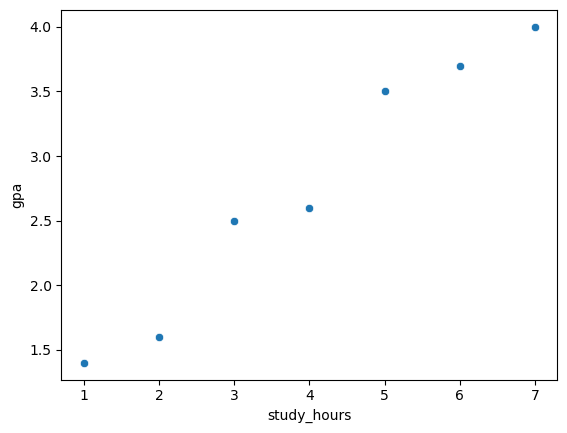

In [5]:
sns.scatterplot(x='study_hours',y='gpa',data=df);

### Calculate  $\beta_1$:
In the case of a model with a single predictor $x$, there is a fairly straightforward **linear least squares** formula we can use to estimate $\beta_1$: 


<center><font face = "Courier New" color=red size=4>$\large \hat{\beta}_1 =$</font> <font face = "Courier New" color=red size=5>$\large\frac{    \bar{(x_iy_i)} - \bar{x_i} {\bar{y_i}}}      {\bar{x_i^2} - \bar{x_i}^2}\hspace{4cm}$</font><br><br>
    
    
<center><font face = "Courier New" color=red size=4>$\large \hat{\beta}_1 =$</font> <font face = "Courier New" color=red size=5>$\large \frac{\text{cov}(x,y)}{\sigma^2_x}\hspace{4cm}$</font><br><br>
    
<center><font face = "Courier New" color=red size=4>$$ \large \hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}\hspace{2.4cm}$$
 </font></center><br><br>
    <center><font face = "Courier New" color=red size=4>$$ \large \hat{\beta}_1 = \frac{n\sum x_iy_i - \sum x_i\sum y_i}{n\sum x_i^2 - (\sum x_i)^2}                  \hspace{1cm}\hspace{.5 cm}$$
 </font></center>

In [6]:
# first formula derived by equating differentiated function to zero
numerator = np.mean(X*y) - (np.mean(X)*np.mean(y))
denominator = np.mean(X**2) - np.mean(X)**2
beta1 = numerator/denominator
beta1

0.4642857142857144

In [7]:
# second formula using covariance
numerator = np.cov(X,y)[0][1]
denominator = (np.std(X,ddof=1))**2
beta1 = numerator/denominator
beta1

0.46428571428571414

In [8]:
# third formula
numerator = np.sum((X-np.mean(X))*(y-np.mean(y)))
denominator = np.sum((X - np.mean(X))  **2)
beta1 = numerator/denominator
beta1

0.4642857142857143

In [9]:
# fourth formula
numerator = (len(X) * np.sum(X*y)) - (np.sum(X)*np.sum(y))
denominator = (len(X)*np.sum(X**2)) - ((np.sum(X))**2)
beta1 = numerator/denominator
beta1

0.4642857142857143

### Calculate  $\beta_0$:
<center><font face = "Courier New" color=red size=4>$\large \beta_0 = \bar{y} - \beta_1\bar{x}$</font><br><br>

In [10]:
beta0 = np.mean(y) - beta1 * np.mean(X)
beta0

0.8999999999999999

### Fit the Line:

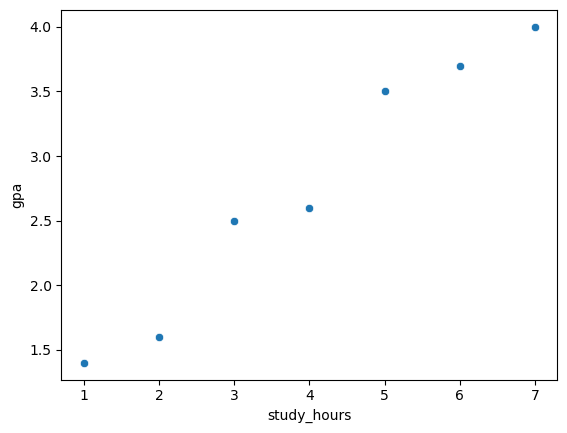

In [11]:
sns.scatterplot(x='study_hours',y='gpa',data=df)
xpointsofline = np.linspace(-1, 7, 100)
ypointsofline = beta0 + beta1 * xpointsofline
#sns.lineplot(x=xpointsofline, y=ypointsofline);

<center><font face = "Courier New" color=red size=4>$ \large \hat{y}_i = \hat{\beta}_0 + \beta_1 x_i $</font>


###  Carry out the Prediction:
<font face = "Arial" color=red size=3>A student has studied for 4.5 hours per day in the entire semester. Can you predict his/her GPA? </font>
<center><font face = "Courier New" color=red size=4>$ \large \hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i $</font>


In [12]:
sh = 4.5
gpa = beta0 + beta1 * sh
print("If a student studies 4.5 hours daily, his/her predicted GPA is: {:.3f}".format(gpa))

If a student studies 4.5 hours daily, his/her predicted GPA is: 2.989


**Visualize:**

beta0: 0.8999999999999999, beta1: 0.4642857142857143


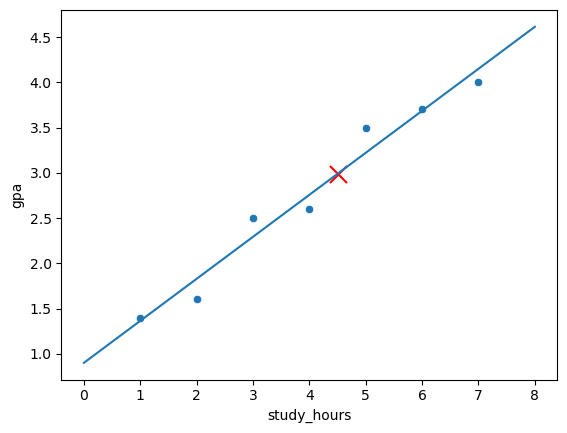

In [13]:
sns.scatterplot(x='study_hours',y='gpa',data=df)
xpointsofline = np.linspace(0, 8, 1000)
ypointsofline = beta0 + beta1 * xpointsofline
sns.lineplot(x=xpointsofline, y=ypointsofline);
print("beta0: {}, beta1: {}".format(beta0,beta1))
plt.scatter(sh, gpa, marker='x',s=150, color='red');

# 4. How to Evaluate the Regression Models?

## a. Evaluation Metrics:

<img align="right" width="600"  src="images/reg-int7.png"  >
<br><br>
$$ \large MAE = \frac{1}{n}\sum_{i=1}^n|y_i - \hat{y}_i|$$ <br><br>

$$ \large MSE = \frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2$$<br><br>

$$ \large RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2}$$<br><br>
<br><br><br><br>

<center><font face = "Comic sans MS" color=green size=6>$ \large R^2 =  1 - \frac{SSE}{SST}$</font></center>
    




<img align="center" width="900"  src="images/r2-image.png"  >

In [22]:
X = np.array(df['study_hours'])
y = np.array(df['gpa'])
ybar = np.mean(y)
yhat = beta0 + beta1*X
mae = (np.sum(abs(y - yhat)))/len(y)
mse = (np.sum((y - yhat)**2))/len(y)
rmse = np.sqrt((np.sum((y - yhat)**2))/len(y))
sse = np.sum((y - yhat)**2)
sst = np.sum((y - ybar)**2)
r2 = 1 - sse/sst
print("MAE: {:.3f}".format(mae))
print("MSE: {:.3f}".format(mse))
print("RMSE: {:.3f}".format(rmse))
print("R2: {:.3f}".format(r2))

MAE: 0.153
MSE: 0.032
RMSE: 0.178
R2: 0.965


## b. Residual Plots, Homoscedasticity and Heteroscedasticity

- The residual analysis also tells us whether or not the model we have trained is actually appropriate for a specific data set.
- There are many machine learning models and some are more appropriate than others and the residuals can help us decide that, i.e., which model we should choose for our application.

<img align="center" width="1000"  src="images/homo-hetero.png"  >

# Task-A

In [14]:
import pandas as pd
df = pd.read_csv("datasets/advertising1D.csv")
df

,expenditure,sales
0,337.1,22.1
1,128.9,10.4
2,132.4,9.3
3,251.3,18.5
4,250.0,12.9
...,...,...
195,55.7,7.6
196,107.2,9.7
197,192.7,12.8
198,391.8,25.5


#  Task To Do: Anscombe's Quartet

https://www.sjsu.edu/faculty/gerstman/StatPrimer/anscombe1973.pdf

- Anscombe’s quartet was constructed in 1973 by statistician Francis Anscombe to illustrate the importance of plotting data before you analyze it and build your model. 
- Anscombe's quartet comprises four data sets that have nearly identical simple descriptive statistics, yet have very different distributions and appear very different when graphed. 
- Each dataset consists of eleven (x,y) points. 
- They were constructed in 1973 by the statistician Francis Anscombe to demonstrate both the importance of graphing data when analyzing it, and the effect of outliers and other influential observations on statistical properties. 
- They all have nearly identical descriptive statistics:
    - Mean of all four x columns is 9.0
    - Mean of all four y columns is 7.5
    - Variance of all four x columns is 11.0
    - Variance of all four y columns is 4.125
    - Correlation between x and y is 0.816
    - Applying a Linear Regression model to fit a best fit line, the slope of regression line for all the four datasets comes 0.5 and the y-intercept 3. $$\large y = 3 + 0.5x$$
<img align="center" width="1000"  src="images/anscombe-quartet1.png"  >

> **This teaches us the importance of visualizing data instead of relying solely on summary statistics when exploring data**

**Load the Anscombe's Quartet Dataset:**

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
df_anscombe = sns.load_dataset('anscombe')
df_anscombe.sample(10)

,dataset,x,y
29,III,4.0,5.39
31,III,7.0,6.42
39,IV,8.0,5.25
41,IV,8.0,5.56
25,III,9.0,7.11
38,IV,8.0,7.04
1,I,8.0,6.95
27,III,14.0,8.84
42,IV,8.0,7.91
35,IV,8.0,7.71


**Query the Dataset-I:**

In [3]:
df_anscombe.query("dataset=='I'")

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


In [22]:
x_1 = df_anscombe.query("dataset=='I'").iloc[:,1]
y_1 = df_anscombe.query("dataset=='I'").iloc[:,2]
print("Mean of x for Dataset-I: ", x_1.mean())
print("Mean of y for Dataset-I: ", y_1.mean())

print("Variance of x for Dataset-I: ", x_1.var())
print("Variance of y for Dataset-I: ", y_1.var())
print("Corrcoef(x,y) for Dataset-I: ", np.corrcoef(x_1, y_1)[0,1])

Mean of x for Dataset-I:  9.0
Mean of y for Dataset-I:  7.500909090909093
Variance of x for Dataset-I:  11.0
Variance of y for Dataset-I:  4.127269090909091
Corrcoef(x,y) for Dataset-I:  0.81642051634484


**Query the Dataset-II:**

In [5]:
df_anscombe.query("dataset=='II'")

,dataset,x,y
11,II,10.0,9.14
12,II,8.0,8.14
13,II,13.0,8.74
14,II,9.0,8.77
15,II,11.0,9.26
16,II,14.0,8.10
17,II,6.0,6.13
18,II,4.0,3.10
19,II,12.0,9.13
20,II,7.0,7.26


In [6]:
x_2 = df_anscombe.query("dataset=='II'").iloc[:,1]
y_2 = df_anscombe.query("dataset=='II'").iloc[:,2]
print("Mean of x for Dataset-II: ", x_2.mean())
print("Mean of y for Dataset-II: ",y_2.mean())

print("Variance of x for Dataset-II: ", x_2.var())
print("Variance of y for Dataset-II: ", y_2.var())
print("Corrcoef(x,y) for Dataset-II: ", np.corrcoef(x_2, y_2)[0,1])

Mean of x for Dataset-II:  9.0
Mean of y for Dataset-II:  7.50090909090909
Variance of x for Dataset-II:  11.0
Variance of y for Dataset-II:  4.127629090909091
Corrcoef(x,y) for Dataset-II:  0.8162365060002427


**Query the Dataset-III:**

In [7]:
df_anscombe.query("dataset=='III'")

,dataset,x,y
22,III,10.0,7.46
23,III,8.0,6.77
24,III,13.0,12.74
25,III,9.0,7.11
26,III,11.0,7.81
27,III,14.0,8.84
28,III,6.0,6.08
29,III,4.0,5.39
30,III,12.0,8.15
31,III,7.0,6.42


In [8]:
x_3 = df_anscombe.query("dataset=='III'").iloc[:,1]
y_3 = df_anscombe.query("dataset=='III'").iloc[:,2]
print("Mean of x for Dataset-III: ", x_3.mean())
print("Mean of y for Dataset-III: ", y_3.mean())

print("Variance of x for Dataset-III: ", x_3.var())
print("Variance of y for Dataset-III: ", y_3.var())
print("Corrcoef(x,y) for Dataset-III: ", np.corrcoef(x_3, y_3)[0,1])

Mean of x for Dataset-III:  9.0
Mean of y for Dataset-III:  7.5
Variance of x for Dataset-III:  11.0
Variance of y for Dataset-III:  4.12262
Corrcoef(x,y) for Dataset-III:  0.8162867394895982


**Query the Dataset-IV:**

In [9]:
df_anscombe.query("dataset=='IV'")

,dataset,x,y
33,IV,8.0,6.58
34,IV,8.0,5.76
35,IV,8.0,7.71
36,IV,8.0,8.84
37,IV,8.0,8.47
38,IV,8.0,7.04
39,IV,8.0,5.25
40,IV,19.0,12.50
41,IV,8.0,5.56
42,IV,8.0,7.91


In [10]:
x_4 = df_anscombe.query("dataset=='IV'").iloc[:,1]
y_4 = df_anscombe.query("dataset=='IV'").iloc[:,2]
print("Mean of x for Dataset-IV: ", x_4.mean())
print("Mean of y for Dataset-IV: ", y_4.mean())

print("Variance of x for Dataset-IV: ", x_4.var())
print("Variance of y for Dataset-IV: ", y_4.var())
print("Corrcoef(x,y) for Dataset-IV: ", np.corrcoef(x_4, y_4)[0,1])

Mean of x for Dataset-IV:  9.0
Mean of y for Dataset-IV:  7.500909090909091
Variance of x for Dataset-IV:  11.0
Variance of y for Dataset-IV:  4.12324909090909
Corrcoef(x,y) for Dataset-IV:  0.8165214368885031


**Best Fit Line on Dataset-I**

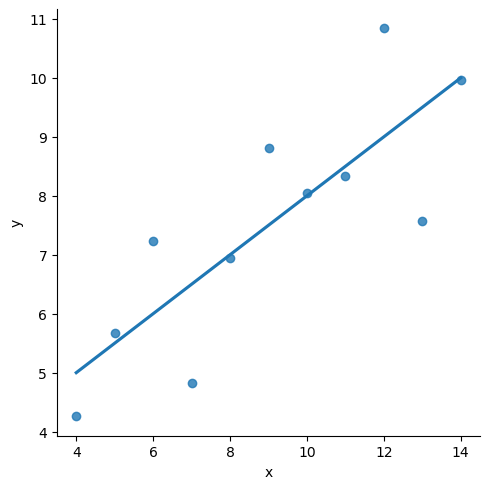

In [17]:
%matplotlib inline
sns.lmplot(x="x", 
           y="y", 
           data=df_anscombe.query("dataset=='I'"),
           ci=None
          );

**Best Fit Line on Dataset-II**

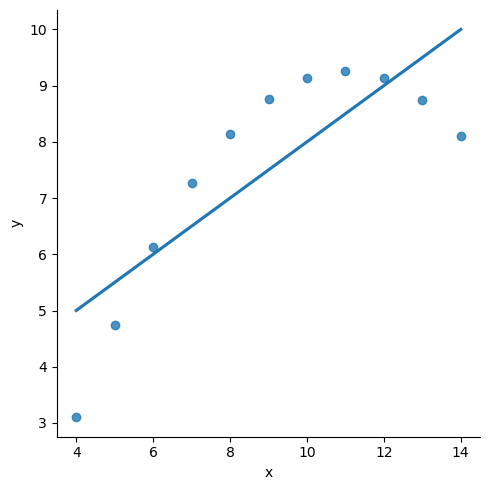

In [19]:
sns.lmplot(x="x", 
           y="y", 
           data=df_anscombe.query("dataset=='II'"),
           ci=None
          );

**Best Fit Line on Dataset-III**

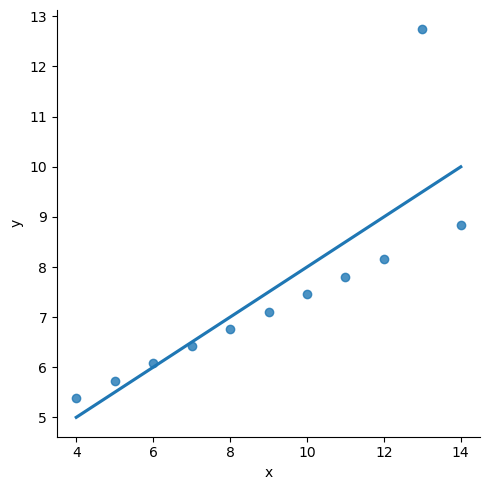

In [20]:
sns.lmplot(x="x", 
           y="y", 
           data=df_anscombe.query("dataset=='III'"),
           ci=None
          );

**Best Fit Line on Dataset-IV**

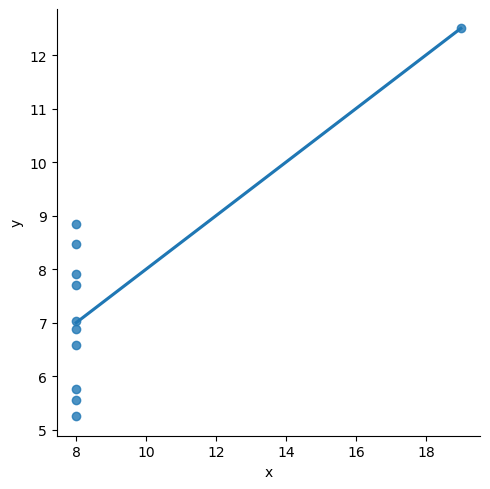

In [21]:
sns.lmplot(x="x", 
           y="y", 
           data=df_anscombe.query("dataset=='IV'"),
           ci=None
          );